# Grid Search

In [482]:
import warnings
warnings.filterwarnings("ignore")

Grid Search is a hyperparameter tuning technique used to find the best combination of parameters for a machine learning model.

In simple terms, it:

    Defines a grid of possible values for each hyperparameter.

    Trains and evaluates the model for every combination of those values.

    Selects the combination that gives the best performance (based on cross-validation

In [483]:
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [484]:
df = pd.read_csv("./data/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [485]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


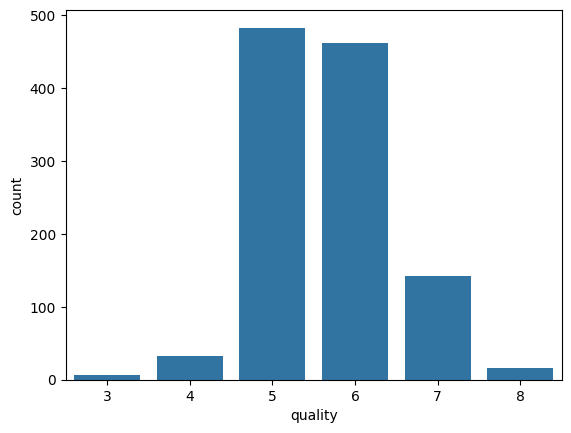

In [486]:
sns.countplot(x='quality', data=df)
plt.show()

In [487]:

X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [488]:
# Define the model 
lr = LogisticRegression()


In [489]:
# Fit model 
lr.fit(X_train,y_train)
print("Trained")

Trained


In [490]:
y_pred = lr.predict(X_test)

In [491]:
print(classification_report(y_pred=y_pred,y_true=y_test))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.63      0.76      0.69        96
           6       0.59      0.63      0.61        99
           7       0.56      0.19      0.29        26
           8       0.00      0.00      0.00         2

    accuracy                           0.61       229
   macro avg       0.36      0.32      0.32       229
weighted avg       0.58      0.61      0.59       229



### Grid Search 

In [492]:
# Define the model 
lr = LogisticRegression()

In [493]:
# example grid
lr_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ['liblinear']
}

In [494]:
# lr_grid = [
#     # L1 regularization
#     {
#         "penalty": ["l1"],
#         "C": [0.0001, 0.001, 0.01, 0.1, 1, 10],
#         "solver": ["liblinear", "saga"],
#         "max_iter": [1000]
#     },
    
#     # L2 regularization
#     {
#         "penalty": ["l2"],
#         "C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
#         "solver": ["lbfgs", "liblinear", "saga"],
#         "max_iter": [1000]
#     },
    
#     # ElasticNet (only works with saga)
#     {
#         "penalty": ["elasticnet"],
#         "C": [0.001, 0.01, 0.1, 1, 10],
#         "solver": ["saga"],
#         "l1_ratio": [0.2, 0.5, 0.8],
#         "max_iter": [1000]
#     }
# ]

In [495]:
# grid search 
lr_search = GridSearchCV(param_grid=lr_grid,estimator=lr,scoring="accuracy",cv=5)

In [496]:
# fit the model 
lr_search.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [497]:
y_pred = lr_search.predict(X_test)

In [498]:
print(classification_report(y_pred=y_pred,y_true=y_test))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.67      0.78      0.72        96
           6       0.61      0.65      0.63        99
           7       0.42      0.19      0.26        26
           8       0.00      0.00      0.00         2

    accuracy                           0.63       229
   macro avg       0.34      0.32      0.32       229
weighted avg       0.59      0.63      0.60       229



## with scaling 

In [499]:
from sklearn.preprocessing import StandardScaler

In [500]:
scaler = StandardScaler()

In [501]:
X_scaled = scaler.fit_transform(X)

In [502]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42,stratify=y)

In [503]:
lr = LogisticRegression()

In [504]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [505]:
y_pred = lr.predict(X_test)

In [506]:
print(classification_report(y_pred=y_pred,y_true=y_test))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.78      0.74        97
           6       0.59      0.65      0.62        92
           7       0.47      0.31      0.38        29
           8       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.30      0.29      0.29       229
weighted avg       0.60      0.63      0.61       229



## DCT Scaled 

In [507]:
dct = KNeighborsClassifier()

In [508]:
dct.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [509]:
y_pred = dct.predict(X_test)

In [510]:
print(classification_report(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.67      0.66      0.66        97
           6       0.53      0.61      0.57        92
           7       0.40      0.34      0.37        29
           8       0.00      0.00      0.00         3

    accuracy                           0.57       229
   macro avg       0.27      0.27      0.27       229
weighted avg       0.55      0.57      0.56       229



In [511]:
param_grid = {
    'n_neighbors': list(range(1, 21, 2)),  # odd values to avoid ties
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','minkowski']
}

# Grid Search
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 3, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,17


In [512]:

# Use best model
best_model = grid.best_estimator_

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.73      0.73        97
           6       0.62      0.74      0.67        92
           7       0.64      0.48      0.55        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.64      0.67      0.65       229

